# Lab 1 — Forecasting European Airport Traffic with PyTorch
### EUROCONTROL AI Lab · Exercise 1

**Question:** *How many flights will Brussels Airport (EBBR) handle tomorrow?*

We use **real EUROCONTROL data**: the daily number of IFR arrivals and departures per airport, published by the
Aviation Intelligence Unit on the [Aviation Intelligence Portal](https://ansperformance.eu/csv/).

| | |
|---|---|
| ⏱ **Time** | about 2 hours |
| 🎓 **Prerequisites** | none — no programming experience needed |
| 💻 **Hardware** | a normal laptop; every training run takes a few seconds |

**What you will learn**
1. How to **load and look at** a real operational dataset before building any model.
2. How to **frame a forecasting problem**: inputs, target, how to split the data, and simple baselines to compare with.
3. How a **neural network is trained** in PyTorch, step by step.
4. Why **hyperparameters** (learning rate, model size, amount of history) can make the same model good or useless.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

>
> 🧑‍💻 **Optional coding challenges** — a few cells invite those who want to **write code** to try a variation of the exercise.
> They are clearly marked, **switched off** (every line starts with `#`, so running them does nothing) and the rest of the notebook does not depend on them: skip them freely.
> To try one, remove the `#` signs (select the lines and press **Ctrl + /**, or **Cmd + /** on a Mac), fill in the `___` blanks and run the cell.
> The solutions are in the `solutions` folder next to this notebook.

> ✅ **SOLUTIONS NOTEBOOK** — identical to the participant notebook, except that the **optional coding challenges** (🧑‍💻) are solved and executed. Search for 🧑‍💻 to jump to them.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab1_airport_traffic/solutions/Lab1_airport_traffic_SOLUTIONS.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    os.chdir("/content/ai-lab/lab1_airport_traffic/solutions")# work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup
This cell loads the software libraries we need. Think of them as toolboxes: each one brings ready-made functions.

In [2]:
from pathlib import Path                          # Path: builds file paths that work on Windows, macOS and Linux
import time                                       # time: lets us measure how long training takes
import numpy as np                                # numpy: fast calculations on arrays (lists) of numbers
import pandas as pd                               # pandas: tables of data, like a spreadsheet inside Python
import matplotlib.pyplot as plt                   # matplotlib: draws plots
import torch                                      # torch (PyTorch): builds and trains neural networks
import torch.nn as nn                             # torch.nn: building blocks of networks (layers, loss functions)
from torch.utils.data import Dataset, DataLoader  # tools that feed the data to the model in small groups (batches)

SEED = 42                                         # a fixed "seed" for random numbers...
np.random.seed(SEED)                              # ...used by numpy...
torch.manual_seed(SEED)                           # ...and by PyTorch, so everybody gets exactly the same results

DATA_DIR = Path("../data")                        # the data folder sits next to this lab's folder
if not DATA_DIR.exists():                         # if it is not there (e.g. notebook opened from the solutions folder)...
    DATA_DIR = Path("../../data")                 # ...look one folder higher
if not DATA_DIR.exists():                         # if still not found (notebook opened from the main folder)...
    DATA_DIR = Path("data")                       # ...look inside the current folder

print("PyTorch version:", torch.__version__)      # show the PyTorch version (useful if something does not work)
print("pandas version :", pd.__version__)         # show the pandas version

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

PyTorch version: 2.14.0+cu130
pandas version : 3.0.2


---
## 1 · Load the data

The data comes as **one CSV file per year** (CSV = a text file with one row per line and values separated by commas).
We have 2019 (before COVID) and 2023, 2024, 2025. We read the four files and stack them into one table.

In [3]:
years = [2019, 2023, 2024, 2025]                          # the years we want to load
tables = []                                               # an empty list that will collect one table per year

for year in years:                                        # repeat the next lines for each year in the list
    file_name = "airport_traffic_" + str(year) + ".csv"   # build the file name, e.g. "airport_traffic_2024.csv"
    one_year = pd.read_csv(DATA_DIR / file_name)          # read the CSV file into a table (a pandas "DataFrame")
    tables.append(one_year)                               # add this year's table to the list
    print(file_name, "->", len(one_year), "rows")         # show how many rows the file has

traffic = pd.concat(tables, ignore_index=True)            # stack the four yearly tables into one big table
traffic["FLT_DATE"] = pd.to_datetime(traffic["FLT_DATE"]) # turn the date column from text into real dates

print("Full table (rows, columns):", traffic.shape)       # show the size of the full table
traffic.head()                                            # display the first 5 rows

airport_traffic_2019.csv -> 113975 rows


airport_traffic_2023.csv -> 114115 rows


airport_traffic_2024.csv -> 129302 rows


airport_traffic_2025.csv -> 130295 rows
Full table (rows, columns): (487687, 13)


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
0,2019,1,JAN,2019-01-01,LATI,Tirana,Albania,29,26,55,NaN,NaN,NaN
1,2019,1,JAN,2019-01-01,UDYZ,Yerevan,Armenia,29,33,62,NaN,NaN,NaN
2,2019,1,JAN,2019-01-01,LOWG,Graz,Austria,5,7,12,NaN,NaN,NaN
3,2019,1,JAN,2019-01-01,LOWI,Innsbruck,Austria,28,26,54,NaN,NaN,NaN
4,2019,1,JAN,2019-01-01,LOWK,Klagenfurt,Austria,4,4,8,NaN,NaN,NaN


**What the columns mean**

| Column | Meaning |
|---|---|
| `FLT_DATE` | the day |
| `APT_ICAO`, `APT_NAME` | the airport (ICAO code and name), e.g. EBBR = Brussels |
| `FLT_DEP_1`, `FLT_ARR_1`, `FLT_TOT_1` | IFR departures, arrivals and **total movements**, from the EUROCONTROL Network Manager |
| `..._IFR_2` | the same counts reported by the airport operator — available only for some airports, often empty |

👉 **One row = one airport on one day.** We will use **`FLT_TOT_1`** (total movements) because it is always filled in.

---
## 2 · Look at the data before modelling

Before building any model we look at the data. Every observation here will guide a later decision.

### 2.1 How much data do we have?

In [4]:
first_day = traffic["FLT_DATE"].min()                     # the earliest date in the table
last_day = traffic["FLT_DATE"].max()                      # the latest date in the table
print("From", first_day.date(), "to", last_day.date())    # show the period covered
print("Number of airports:", traffic["APT_ICAO"].nunique())  # count the different airport codes
print("Number of days    :", traffic["FLT_DATE"].nunique())  # count the different dates

From 2019-01-01 to 2025-12-31
Number of airports: 380
Number of days    : 1461


### 2.2 Our airport: Brussels (EBBR)
We keep only the rows of Brussels and put them in date order.

In [5]:
AIRPORT = "EBBR"                                                # the airport we study (try "LIRF" for Rome later)

airport_rows = traffic[traffic["APT_ICAO"] == AIRPORT]          # keep only the rows of this airport
airport_rows = airport_rows[["FLT_DATE", "FLT_TOT_1"]]          # keep only two columns: date and total movements
airport_rows = airport_rows.sort_values("FLT_DATE")             # sort the rows from the oldest to the newest date
airport_rows = airport_rows.set_index("FLT_DATE")               # use the date as the label of each row
series = airport_rows["FLT_TOT_1"]                              # one column labelled by date = a "time series"

print("Days available for", AIRPORT, ":", len(series))          # how many days we have
print("Average movements per day:", round(series.mean()))       # the average daily traffic
print("Minimum:", series.min(), "  Maximum:", series.max())     # the lowest and highest daily traffic

Days available for EBBR : 1461
Average movements per day: 555
Minimum: 41   Maximum: 780


### 2.3 Is traffic back to pre-COVID levels?

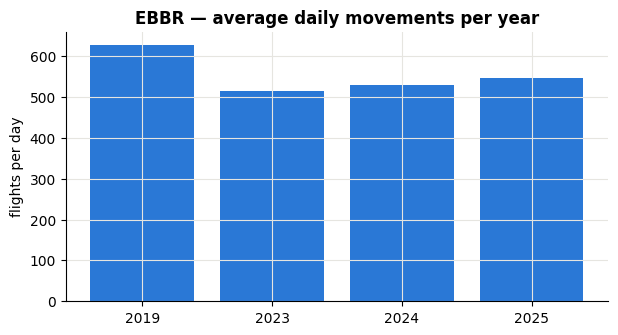

In [6]:
years_of_each_day = series.index.year                            # the year of each date
average_per_year = series.groupby(years_of_each_day).mean()      # average traffic for each year

plt.figure(figsize=(7, 3.5))                                     # start a new figure, 7 x 3.5 inches
year_labels = average_per_year.index.astype(str)                 # the years as text, used as bar labels
plt.bar(year_labels, average_per_year.values, color=PALETTE[0])  # draw one bar per year
plt.title(AIRPORT + " — average daily movements per year")       # title of the plot
plt.ylabel("flights per day")                                    # label of the vertical axis
plt.show()                                                       # display the figure

📖 **Reading:** traffic is growing again, but in 2025 it is still about 13 % below 2019. The years 2020–2022 (COVID) are not in our files on purpose: they would confuse a small forecasting model. From now on we use only the continuous period **2023–2025**.

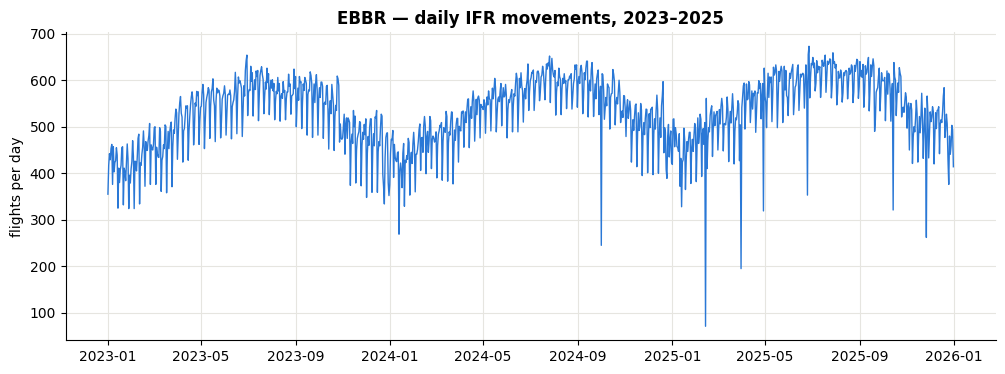

In [7]:
series = series[series.index >= "2023-01-01"]                    # keep only the days from 1 January 2023 onwards

plt.figure(figsize=(12, 4))                                      # start a new figure, 12 x 4 inches
plt.plot(series.index, series.values, linewidth=1, color=PALETTE[0])  # draw the daily traffic as a line
plt.title(AIRPORT + " — daily IFR movements, 2023–2025")         # title
plt.ylabel("flights per day")                                    # label of the vertical axis
plt.show()                                                       # display the figure

📖 **Reading:** three things are visible:
- a **yearly pattern** — busier in summer, quieter in winter;
- a **weekly pattern** — the line goes up and down every week (this makes the line look "thick");
- a few **sudden drops** — single days with far fewer flights.

### 2.4 The weekly pattern

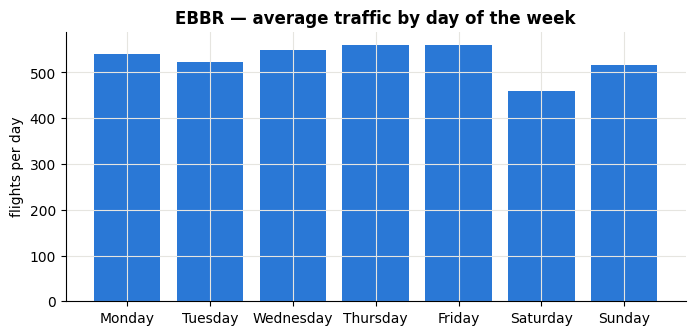

In [8]:
weekday_names = series.index.day_name()                          # the name of the weekday of each date (Monday, ...)
average_per_weekday = series.groupby(weekday_names).mean()       # average traffic for each weekday

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]  # usual order of days
average_per_weekday = average_per_weekday.reindex(week_order)    # put the averages in that order (not alphabetical)

plt.figure(figsize=(8, 3.5))                                     # start a new figure
plt.bar(week_order, average_per_weekday.values, color=PALETTE[0])  # one bar per weekday
plt.title(AIRPORT + " — average traffic by day of the week")     # title
plt.ylabel("flights per day")                                    # label of the vertical axis
plt.show()                                                       # display the figure

📖 **Reading:** Saturday is clearly the quietest day. So the **day of the week** of the day we want to predict is useful information for the model.

### 🧑‍💻 Optional coding challenge A — the monthly pattern
*Optional, for those who want to write code — the rest of the notebook does not depend on it.*

**Task:** draw the average traffic for each **month** (1 = January … 12 = December), like the weekday chart above.
**Variation:** change `AIRPORT` in §2.2 to a holiday airport (e.g. `"LPPT"` Lisbon or `"LGAV"` Athens), re-run and compare the summer peak with Brussels.

Solution: `solutions/Lab1_airport_traffic_SOLUTIONS.ipynb`

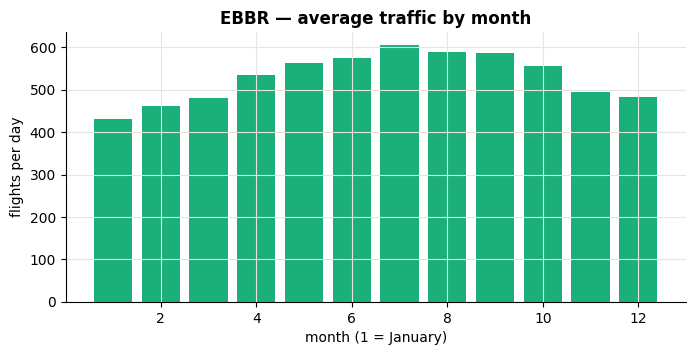

In [9]:
# 🧑‍💻 OPTIONAL CHALLENGE A — SOLUTION
month_of_each_day = series.index.month                       # the month (1–12) of each date
average_per_month = series.groupby(month_of_each_day).mean() # average traffic for each month

plt.figure(figsize=(8, 3.5))                                 # start a new figure
plt.bar(average_per_month.index, average_per_month.values, color=PALETTE[2])   # one bar per month
plt.title(AIRPORT + " — average traffic by month")           # title
plt.xlabel("month (1 = January)")                            # horizontal axis label
plt.ylabel("flights per day")                                # vertical axis label
plt.show()                                                   # display the figure
# Reading: summer months (June–September) are the busiest; January and February the quietest.

### 2.5 The unusual days

In [10]:
sorted_days = series.sort_values()                               # all days, sorted from the lowest to the highest traffic
lowest_days = sorted_days.head(8)                                # keep the first 8 = the 8 lowest days

lowest_table = pd.DataFrame({"flights": lowest_days})            # put them in a small table
lowest_table["weekday"] = lowest_days.index.day_name()           # add a column with the name of the weekday
lowest_table                                                     # display the table

,flights,weekday
FLT_DATE,,
2025-02-13,71,Thursday
2025-03-31,195,Monday
2024-10-01,245,Tuesday
2025-11-26,262,Wednesday
2024-01-13,269,Saturday
2025-04-29,319,Tuesday
2025-10-14,321,Tuesday
2023-02-04,324,Saturday


🗣 **Discussion:** most of these days are **national strikes or industrial action** in Belgium (for example 13 February and 31 March 2025).
They are real, but **impossible to predict from past traffic alone**. We keep them in the data — and we will see that they produce the model's biggest errors.

### 2.6 Is yesterday or last week a better guide to today?
Each dot below is one day: its traffic compared with the traffic **the day before** (left) and **7 days before** (right).
If the dots lie close to the diagonal, the past day is a good guide.

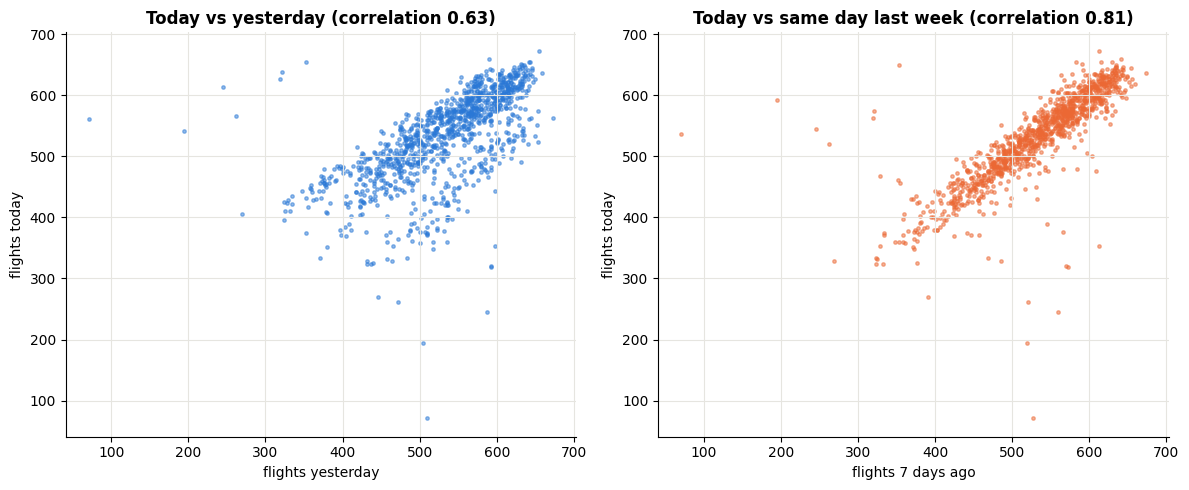

In [11]:
yesterday = series.shift(1)                                      # for each day, the traffic of the day before
last_week = series.shift(7)                                      # for each day, the traffic 7 days before

corr_yesterday = series.corr(yesterday)                          # correlation today/yesterday (1 = perfectly related)
corr_last_week = series.corr(last_week)                          # correlation today/same weekday last week

fig, axes = plt.subplots(1, 2, figsize=(12, 5))                  # a figure with two plots side by side

axes[0].scatter(yesterday, series, s=6, alpha=0.5, color=PALETTE[0])   # left: one dot per day, yesterday vs today
axes[0].set_title("Today vs yesterday (correlation " + str(round(corr_yesterday, 2)) + ")")  # left title
axes[0].set_xlabel("flights yesterday")                          # left horizontal axis label
axes[0].set_ylabel("flights today")                              # left vertical axis label

axes[1].scatter(last_week, series, s=6, alpha=0.5, color=PALETTE[1])   # right: one dot per day, last week vs today
axes[1].set_title("Today vs same day last week (correlation " + str(round(corr_last_week, 2)) + ")")  # right title
axes[1].set_xlabel("flights 7 days ago")                         # right horizontal axis label
axes[1].set_ylabel("flights today")                              # right vertical axis label

plt.tight_layout()                                               # adjust the spacing between the two plots
plt.show()                                                       # display the figure

📖 **Reading:** the dots are much closer to a line on the right. **The same weekday last week is a better predictor than yesterday** — because of the weekly pattern.
So the model should see **at least the last 7 days** of traffic.

> **🧭 What the data told us**
> - we predict `FLT_TOT_1` (always available) for EBBR, using 2023–2025
> - strong weekly pattern → give the model the last days of traffic **and** the day of the week
> - a few unpredictable disruption days → some large errors are unavoidable

---
## 3 · Frame the problem

| | |
|---|---|
| **Inputs** | the traffic of the last few days + the day of the week of the day to predict |
| **Target** | the traffic of the next day |
| **Error measure** | **MAE** — *mean absolute error*: on average, how many flights the forecast is wrong by |
| **Split** | **by time**: train on 2023–2024 · *validation* on Jan–Jun 2025 · *test* on Jul–Dec 2025 |

**Why three parts?**
- **training** data: the model learns from it;
- **validation** data: we use it to compare different settings (hyperparameters);
- **test** data: used **once**, at the very end, to get an honest final score.

⚠️ We split **by time**, not at random: in real life we never know the future when we make a forecast. A random split would let the model "peek" at days after the one it predicts (this is called **data leakage**).

### 3.1 Simple forecasts to beat (baselines)
Before using AI, we check two trivial forecasts:
- **"same as yesterday"**
- **"same as the same weekday last week"**

In [12]:
VALIDATION_START = "2025-01-01"                                  # first day of the validation period
TEST_START = "2025-07-01"                                        # first day of the test period

is_train = series.index < VALIDATION_START                       # True for the days before 2025 (training period)
is_validation = (series.index >= VALIDATION_START) & (series.index < TEST_START)  # True for Jan–Jun 2025
is_test = series.index >= TEST_START                             # True for Jul–Dec 2025

forecast_yesterday = series.shift(1)                             # baseline 1: tomorrow = today
forecast_last_week = series.shift(7)                             # baseline 2: tomorrow = same weekday last week

error_yesterday = (forecast_yesterday - series).abs()            # size of the error of baseline 1, day by day
error_last_week = (forecast_last_week - series).abs()            # size of the error of baseline 2, day by day

mae_yesterday = error_yesterday[is_validation].mean()            # average error of baseline 1 on validation days
mae_last_week = error_last_week[is_validation].mean()            # average error of baseline 2 on validation days

print("Validation MAE, 'same as yesterday'     :", round(mae_yesterday, 1), "flights")  # show baseline 1
print("Validation MAE, 'same weekday last week':", round(mae_last_week, 1), "flights")  # show baseline 2

BASELINE_MAE = mae_last_week                                     # remember the best baseline: the number to beat

Validation MAE, 'same as yesterday'     : 54.6 flights
Validation MAE, 'same weekday last week': 33.5 flights


📖 **Reading:** *"same weekday last week"* is much better than *"same as yesterday"*, as the scatter plots suggested. **This is the number our neural network has to beat.**

---
## 4 · Prepare the data for the neural network

### 4.1 From a time series to examples
A neural network learns from **examples**, each made of *inputs* and the *correct answer*.
We slide a window along the series: the traffic of the last `LOOKBACK` days (plus the day of the week) is the input, the next day is the answer.

```
days:     t-7  t-6  t-5  t-4  t-3  t-2  t-1  |  t
          └──────────── inputs ────────────┘    └ answer
```

**What one example looks like.** With a look-back of 14 days, each example has **21 input numbers**:
the traffic of the 14 previous days, followed by **7 "switches" that say which weekday we are forecasting**.
Only the switch of that weekday is 1, the other six are 0 (this is called **one-hot encoding**).
For example, to forecast **Saturday 15 March**:

```
[ traffic 1 Mar, 2 Mar, … , 14 Mar ]   +   [  0    0    0    0    0    1    0  ]
  └──── 14 numbers (scaled) ────┘            Mon  Tue  Wed  Thu  Fri  Sat  Sun
                                             └─ 7 numbers: "the day to forecast is a Saturday" ─┘
= 21 numbers  →  the answer the model must learn to give: the traffic on Saturday 15 March
```
To forecast a Monday, the last part would be `[1, 0, 0, 0, 0, 0, 0]`.

**How the network uses the switches.** Every input has its own **weight** (a number learned during training).
Each neuron of the first layer multiplies every input by its weight and adds everything up:

```
one neuron =  w1 × (traffic day 1) + w2 × (traffic day 2) + … + w14 × (traffic day 14)    ← "how busy has the airport been?"
            + wMon × 0 + wTue × 0 + wWed × 0 + wThu × 0 + wFri × 0 + wSat × 1 + wSun × 0    ← "what kind of day is it?"

           = (weighted recent traffic)  +  wSat
```
The six switches that are 0 contribute nothing, so **only the weight of the forecast weekday is added**.
During training the network learns one such weight per weekday (in each of its neurons). Since Saturdays are always quieter (§2.4),
it learns Saturday weights that **lower the forecast** whenever the Saturday switch is on.

**Why seven switches and not one number (Monday = 0 … Sunday = 6)?** A single number would suggest an order and a size that do not exist:
Sunday (6) would look "six times" Monday, and Saturday "far" from Monday. Seven separate yes/no switches treat every weekday simply as a different category.

The 14 traffic numbers are scaled around 0 (§4.2); the switches are already 0 or 1 and are left as they are.

In [13]:
def make_examples(series, lookback):                             # define a function; `lookback` = number of past days
    values = series.values.astype("float32")                     # the traffic values as a plain list of numbers
    dates = series.index                                         # the dates of the series

    inputs = []                                                  # empty list for the inputs of each example
    answers = []                                                 # empty list for the correct answer of each example
    answer_dates = []                                            # empty list for the date of each answer

    for t in range(lookback, len(values)):                       # go through the days that have enough history before them
        past_days = values[t - lookback:t]                       # the traffic of the `lookback` days before day t

        weekday_number = dates[t].dayofweek                      # weekday of day t as a number: Monday=0 ... Sunday=6
        weekday_one_hot = np.zeros(7, dtype="float32")           # seven zeros...
        weekday_one_hot[weekday_number] = 1.0                    # ...with a 1 at the weekday position (e.g. Wed = 0010000)

        one_input = np.concatenate([past_days, weekday_one_hot]) # the input = past days followed by the weekday code

        inputs.append(one_input)                                 # store the input of this example
        answers.append(values[t])                                # store the answer: the traffic on day t
        answer_dates.append(dates[t])                            # store the date of the answer

    X = np.array(inputs)                                         # turn the list of inputs into a table of numbers
    y = np.array(answers)                                        # turn the list of answers into an array
    answer_dates = pd.DatetimeIndex(answer_dates)                # turn the list of dates into a date index
    return X, y, answer_dates                                    # give the three results back


X, y, example_dates = make_examples(series, lookback=14)         # try the function with a look-back of 14 days

print("Inputs X  (examples, numbers per example):", X.shape)     # 14 past days + 7 weekday values = 21 numbers
print("Answers y (examples,):", y.shape)                         # one answer per example
print("First example predicts the day", example_dates[0].date()) # the first day that has 14 days of history

Inputs X  (examples, numbers per example): (1082, 21)
Answers y (examples,): (1082,)
First example predicts the day 2023-01-15


### 4.2 Scaling the numbers
Neural networks learn best when numbers are small, around 0. We subtract the average and divide by the spread
(standard deviation) — computed **on the training period only**, so that no information from the future is used.

In [14]:
def prepare_data(lookback):                                      # define a function that prepares everything
    X, y, dates = make_examples(series, lookback)                # build the examples with the chosen look-back

    train = dates < VALIDATION_START                             # True for training examples
    validation = (dates >= VALIDATION_START) & (dates < TEST_START)  # True for validation examples
    test = dates >= TEST_START                                   # True for test examples

    mean = y[train].mean()                                       # average traffic, TRAINING examples only
    std = y[train].std()                                         # spread (standard deviation), TRAINING examples only

    X_scaled = X.copy()                                          # copy the inputs so the original stays unchanged
    X_scaled[:, :lookback] = (X_scaled[:, :lookback] - mean) / std   # scale the traffic columns (weekday code stays 0/1)
    y_scaled = (y - mean) / std                                  # scale the answers the same way

    data = {}                                                    # an empty dictionary (a container with labels)
    data["X"] = X_scaled                                         # scaled inputs
    data["y"] = y_scaled                                         # scaled answers
    data["y_flights"] = y                                        # answers in flights (not scaled), to measure errors
    data["dates"] = dates                                        # date of each answer
    data["train"] = train                                        # which examples are for training
    data["validation"] = validation                              # which examples are for validation
    data["test"] = test                                          # which examples are for testing
    data["mean"] = mean                                          # the average used for scaling
    data["std"] = std                                            # the spread used for scaling
    return data                                                  # give the dictionary back


data = prepare_data(lookback=14)                                 # prepare the data with a 14-day look-back

print("Training average:", round(float(data["mean"]), 1), "flights")    # the average used for scaling
print("Training spread :", round(float(data["std"]), 1), "flights")     # the spread used for scaling
print("Training examples  :", data["train"].sum())               # number of training examples
print("Validation examples:", data["validation"].sum())          # number of validation examples
print("Test examples      :", data["test"].sum())                # number of test examples

Training average: 524.1 flights
Training spread : 70.0 flights
Training examples  : 717
Validation examples: 181
Test examples      : 184


### 4.3 Feeding the data to PyTorch
PyTorch reads data through two helpers:
- a **`Dataset`** knows how to give example number *i*;
- a **`DataLoader`** groups examples into small **batches** (here 32 at a time) and shuffles them at every pass.

In [15]:
class TrafficDataset(Dataset):                                   # a PyTorch Dataset that holds our examples
    def __init__(self, X, y):                                    # runs when the dataset is created
        self.X = torch.tensor(X, dtype=torch.float32)            # store the inputs as a PyTorch "tensor" (array)
        self.y = torch.tensor(y, dtype=torch.float32)            # store the answers as a tensor

    def __len__(self):                                           # PyTorch asks: how many examples are there?
        return len(self.y)                                       # answer: the number of answers

    def __getitem__(self, i):                                    # PyTorch asks: give me example number i
        return self.X[i], self.y[i]                              # answer: its inputs and its correct answer


def make_loaders(data, batch_size):                              # define a function that creates the loaders
    train_X = data["X"][data["train"]]                           # inputs of the training examples
    train_y = data["y"][data["train"]]                           # answers of the training examples
    validation_X = data["X"][data["validation"]]                 # inputs of the validation examples
    validation_y = data["y"][data["validation"]]                 # answers of the validation examples

    train_dataset = TrafficDataset(train_X, train_y)             # dataset with the training examples
    validation_dataset = TrafficDataset(validation_X, validation_y)  # dataset with the validation examples

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # batches, shuffled every epoch
    validation_loader = DataLoader(validation_dataset, batch_size=256, shuffle=False)  # batches, fixed order
    return train_loader, validation_loader                       # give both loaders back


train_loader, validation_loader = make_loaders(data, batch_size=32)  # create the loaders, 32 examples per batch

for batch_inputs, batch_answers in train_loader:                 # take batches from the loader...
    print("One batch of inputs :", batch_inputs.shape)           # 32 examples x 21 numbers
    print("One batch of answers:", batch_answers.shape)          # 32 answers
    break                                                        # ...but stop after the first one (just a check)

One batch of inputs : torch.Size([32, 21])
One batch of answers: torch.Size([32])


---
## 5 · The neural network

A small **multi-layer perceptron (MLP)**: layers of "neurons" connected one after the other.

```
21 inputs → [ 32 neurons ] → [ 32 neurons ] → 1 output (tomorrow's traffic, scaled)
```
- `nn.Linear` = a layer that computes weighted sums of its inputs (the **weights** are what the network learns);
- `nn.ReLU` = a simple non-linear function (keeps positive values, sets negative values to 0) that lets the network learn curves, not only straight lines.

In [16]:
class TrafficMLP(nn.Module):                                     # our neural network, built on PyTorch's nn.Module
    def __init__(self, n_inputs, hidden=32):                     # runs when the model is created
        super().__init__()                                       # standard first line of every PyTorch model
        self.layers = nn.Sequential(                             # a chain of layers applied one after the other:
            nn.Linear(n_inputs, hidden),                         #   layer 1: n_inputs numbers in -> `hidden` numbers out
            nn.ReLU(),                                           #   keep positive values, set negative ones to 0
            nn.Linear(hidden, hidden),                           #   layer 2: hidden -> hidden
            nn.ReLU(),                                           #   again the non-linearity
            nn.Linear(hidden, 1),                                #   output layer: hidden -> 1 number (the forecast)
        )                                                        # end of the chain

    def forward(self, x):                                        # what the model does with a batch of inputs x
        output = self.layers(x)                                  # pass the inputs through the chain of layers
        output = output.squeeze(1)                               # shape (batch, 1) -> (batch,): one number per example
        return output                                            # give the forecasts back


model = TrafficMLP(n_inputs=21)                                  # create a model with 21 inputs (14 days + 7 weekday)
print(model)                                                     # show the structure of the model

number_of_weights = 0                                            # counter of the weights
for parameter in model.parameters():                             # go through each group of weights of the model
    number_of_weights = number_of_weights + parameter.numel()    # add the number of weights in this group
print("Number of weights to learn:", number_of_weights)          # show the total

TrafficMLP(
  (layers): Sequential(
    (0): Linear(in_features=21, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Number of weights to learn: 1793


---
## 6 · Training

Training repeats the same five steps for every batch of examples:
1. **reset** the corrections computed at the previous step;
2. **forward pass**: the model makes its forecasts;
3. **loss**: measure how wrong the forecasts are (here: the average squared error, *MSE*);
4. **backward pass**: compute how each weight should change to reduce the error;
5. **step**: update the weights a little in that direction.

One pass over all the training examples is called an **epoch**.

In [17]:
def train_one_epoch(model, train_loader, loss_function, optimizer):  # one pass over all training batches
    model.train()                                                # put the model in "training mode"
    for inputs, answers in train_loader:                         # take the training batches one by one
        optimizer.zero_grad()                                    # 1. reset the corrections of the previous step
        forecasts = model(inputs)                                # 2. forward pass: the model makes its forecasts
        loss = loss_function(forecasts, answers)                 # 3. measure how wrong the forecasts are
        loss.backward()                                          # 4. compute the correction for every weight
        optimizer.step()                                         # 5. apply the corrections to the weights


def forecast_in_flights(model, data, which_examples):            # forecasts converted back into flights per day
    model.eval()                                                 # put the model in "evaluation mode" (no learning)
    inputs = torch.tensor(data["X"][which_examples])             # the inputs of the requested examples, as a tensor
    with torch.no_grad():                                        # we only predict: no corrections needed (faster)
        forecasts_scaled = model(inputs).numpy()                 # forecasts (scaled), converted to a numpy array
    forecasts_flights = forecasts_scaled * data["std"] + data["mean"]  # undo the scaling -> flights per day
    return forecasts_flights                                     # give the forecasts back


def mean_absolute_error(forecast, truth):                        # the average size of the errors
    errors = np.abs(forecast - truth)                            # size of each error, without sign
    return float(np.mean(errors))                                # their average, as a normal number

The function below puts everything together. Its arguments are the **hyperparameters** — the settings we choose *before* training:
- `lookback`: how many past days the model sees;
- `hidden`: how many neurons per layer (the size of the model);
- `learning_rate`: how big each correction step is;
- `epochs`: how many passes over the training data;
- `batch_size`: how many examples per batch;
- `weight_decay`: a penalty on large weights, used against overfitting (explained later).

In [18]:
def train_model(lookback=14, hidden=32, learning_rate=0.001, epochs=150, batch_size=32, weight_decay=0.0,
                show_progress=False):                            # the values after "=" are the default settings
    torch.manual_seed(SEED)                                      # same random start for every run: fair comparisons

    data = prepare_data(lookback)                                # build and scale the examples
    train_loader, validation_loader = make_loaders(data, batch_size)  # create the batches

    model = TrafficMLP(n_inputs=lookback + 7, hidden=hidden)     # a new, untrained model
    loss_function = nn.MSELoss()                                 # loss = average of the squared errors
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # applies corrections

    train_errors = []                                            # training error after each epoch (in flights)
    validation_errors = []                                       # validation error after each epoch (in flights)
    start_time = time.time()                                     # remember when training started

    for epoch in range(epochs):                                  # repeat for the chosen number of epochs
        train_one_epoch(model, train_loader, loss_function, optimizer)  # one pass over the training data

        train_forecast = forecast_in_flights(model, data, data["train"])        # forecasts on training days
        train_truth = data["y_flights"][data["train"]]                           # true traffic on training days
        train_errors.append(mean_absolute_error(train_forecast, train_truth))   # store the training error

        validation_forecast = forecast_in_flights(model, data, data["validation"])  # forecasts on validation days
        validation_truth = data["y_flights"][data["validation"]]                     # true traffic on validation days
        validation_errors.append(mean_absolute_error(validation_forecast, validation_truth))  # store validation error

        if show_progress and epoch % 25 == 0:                    # every 25 epochs, if asked...
            print("epoch", epoch, "  training error", round(train_errors[-1], 1),
                  "  validation error", round(validation_errors[-1], 1))   # ...print the progress ([-1] = last value)

    result = {}                                                  # a dictionary to collect the results
    result["model"] = model                                      # the trained model
    result["data"] = data                                        # the data it was trained on
    result["train_errors"] = train_errors                        # the training curve
    result["validation_errors"] = validation_errors              # the validation curve
    result["final_train_mae"] = train_errors[-1]                 # training error at the end
    result["final_validation_mae"] = validation_errors[-1]       # validation error at the end
    result["seconds"] = time.time() - start_time                 # how long the training took
    result["settings"] = {"lookback": lookback, "hidden": hidden, "learning_rate": learning_rate,
                          "epochs": epochs, "batch_size": batch_size, "weight_decay": weight_decay}  # the settings used
    return result                                                # give the results back


def plot_learning_curves(results, labels, title):                # draws the curves of one or more training runs
    plt.figure(figsize=(13, 4.8))                                # start a new figure
    for i in range(len(results)):                                # for each run (i = 0, 1, 2, ...)
        result = results[i]                                      # take run number i
        colour = PALETTE[i]                                      # give it its own colour
        final_train = str(round(result["final_train_mae"], 1))            # final training error, as text
        final_validation = str(round(result["final_validation_mae"], 1))  # final validation error, as text
        plt.plot(result["train_errors"], color=colour, linestyle="--", linewidth=1.5,
                 label=labels[i] + " — TRAINING error (dashed), final " + final_train)          # training: dashed line
        plt.plot(result["validation_errors"], color=colour, linestyle="-", linewidth=2.5,
                 label=labels[i] + " — VALIDATION error (solid), final " + final_validation)    # validation: thick solid line
    plt.axhline(BASELINE_MAE, color="black", linestyle=":", linewidth=2,
                label="BASELINE 'same weekday last week' (" + str(round(BASELINE_MAE, 1)) + ")")   # baseline: black dotted
    plt.text(0, BASELINE_MAE + 1, "baseline to beat", color="black", fontsize=9)    # write "baseline" on the plot too
    plt.ylim(0, 60)                                              # vertical axis from 0 to 60 flights
    plt.xlabel("epoch (pass over the training data)")            # horizontal axis label
    plt.ylabel("error (flights per day)")                        # vertical axis label
    plt.title(title)                                             # title
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)   # legend to the right of the plot
    plt.tight_layout()                                           # make room for the legend
    plt.show()                                                   # display the figure

### 6.1 First training run

epoch 0   training error 44.3   validation error 54.7


epoch 25   training error 13.2   validation error 29.1


epoch 50   training error 12.2   validation error 28.8


epoch 75   training error 11.7   validation error 29.6


epoch 100   training error 11.2   validation error 30.3


epoch 125   training error 10.9   validation error 30.7



Training time: 7.1 seconds
Final error on training days  : 10.4 flights
Final error on validation days: 31.1 flights
Baseline to beat              : 33.5 flights


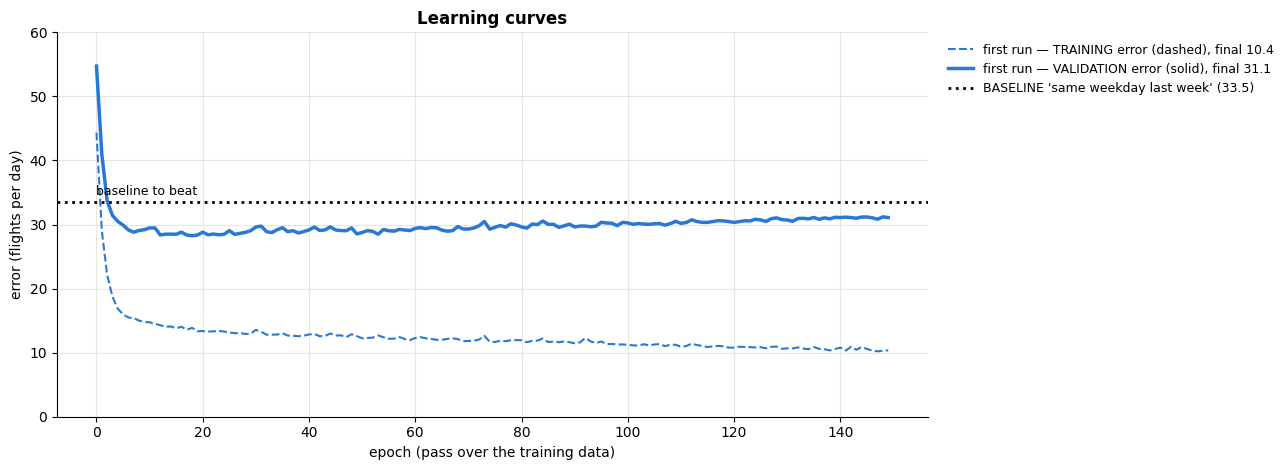

In [19]:
first_run = train_model(show_progress=True)                      # train with the default settings, showing progress

print()                                                          # empty line
print("Training time:", round(first_run["seconds"], 1), "seconds")                            # how long it took
print("Final error on training days  :", round(first_run["final_train_mae"], 1), "flights")    # training error
print("Final error on validation days:", round(first_run["final_validation_mae"], 1), "flights")  # validation error
print("Baseline to beat              :", round(BASELINE_MAE, 1), "flights")                   # the baseline

plot_learning_curves([first_run], ["first run"], "Learning curves")  # draw the learning curves

📖 **Reading the learning curves** (dashed = training, solid = validation, black dotted = baseline):
- Both errors drop quickly in the first ~20 epochs: the model learns the weekly pattern.
- Afterwards the **training** error (dashed) keeps going down, but the **validation** error (solid) stops improving and slowly goes up.
  The model is starting to **memorise** the training days instead of learning general patterns. This is called **overfitting**.
- The validation error cannot go much below ~25 flights: the strike days in the validation period are unpredictable.

---
## 7 · Hyperparameters

The **weights** are learned by the model. The **hyperparameters** are chosen by us, before training.
We now change **one hyperparameter at a time**, keeping everything else the same, and compare the results on the **validation** days.

### 7.1 Learning rate — the size of each correction step

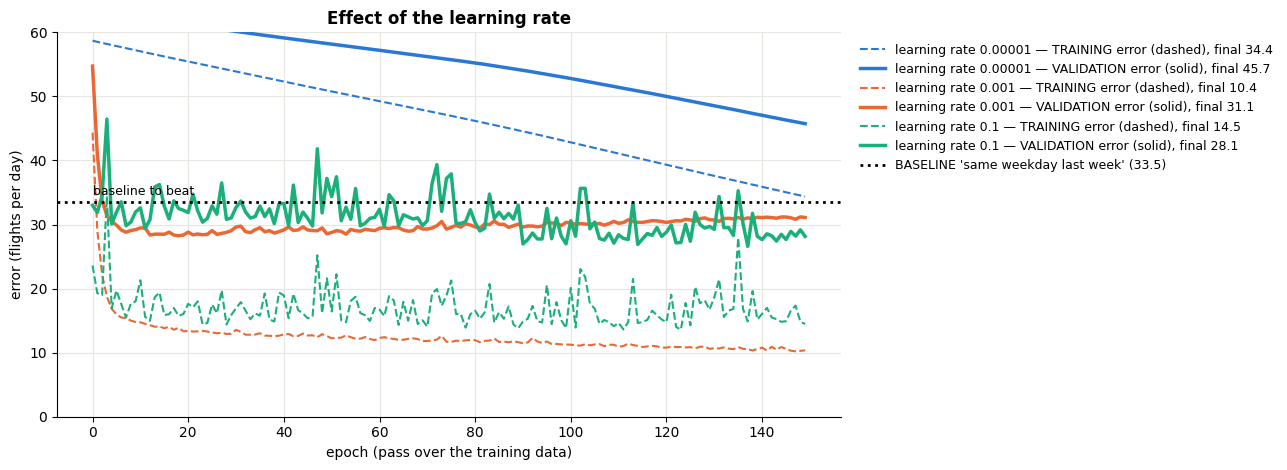

In [20]:
learning_rates = [0.00001, 0.001, 0.1]                           # three learning rates: very small, normal, very large
lr_results = []                                                  # empty list for the results

for lr in learning_rates:                                        # for each learning rate...
    result = train_model(learning_rate=lr)                       # ...train a model...
    lr_results.append(result)                                    # ...and keep its results

lr_labels = ["learning rate 0.00001", "learning rate 0.001", "learning rate 0.1"]  # names for the legend
plot_learning_curves(lr_results, lr_labels, "Effect of the learning rate")        # draw the three runs

📖 **Reading:**
- **too small (0.00001):** the error decreases very slowly — after 150 epochs the model is still worse than the simple baseline.
- **normal (0.001):** fast learning, good result after ~20 epochs.
- **too large (0.1):** the curves jump around — each step overshoots. The final number may look fine by luck, but the training is unstable and unreliable.

### 7.2 Model size and long training — overfitting

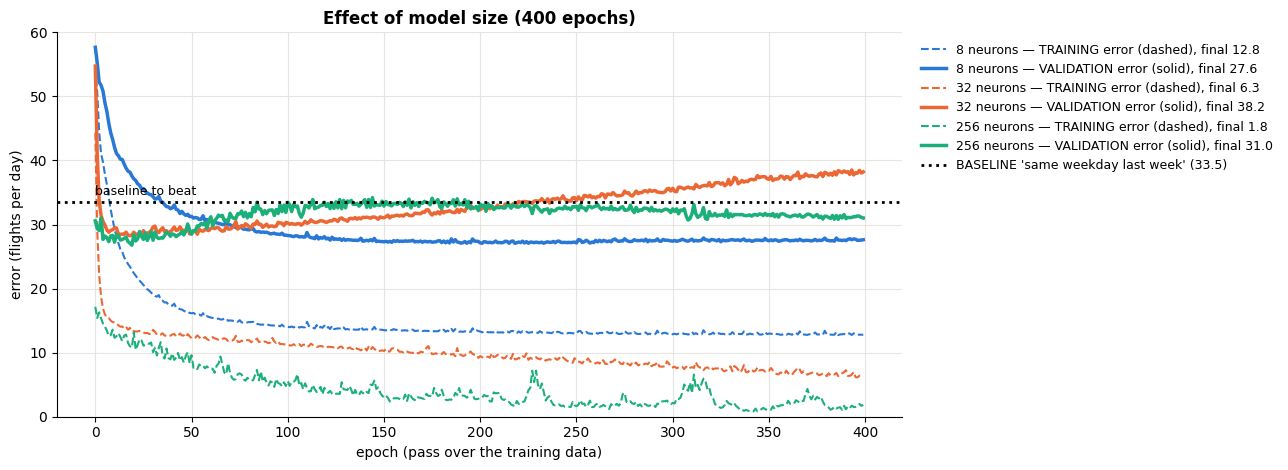

In [21]:
sizes = [8, 32, 256]                                             # three model sizes: neurons per layer
size_results = []                                                # empty list for the results

for size in sizes:                                               # for each size...
    result = train_model(hidden=size, epochs=400)                # ...train for a long time (400 epochs)...
    size_results.append(result)                                  # ...and keep its results

size_labels = ["8 neurons", "32 neurons", "256 neurons"]         # names for the legend
plot_learning_curves(size_results, size_labels, "Effect of model size (400 epochs)")  # draw the three runs

📖 **Reading:**
- The **training** error (dashed) is lower for bigger models: the 256-neuron model (~70 000 weights for only ~700 training days!) gets down to 1–3 flights. It has **memorised** the training days — strikes included.
- The **validation** error (solid) does *not* improve with size, and with long training it drifts upwards.
  A training error of 2 and a validation error of 30 is the classic sign of **overfitting**.

**A remedy: weight decay.** It adds a small penalty for large weights, which prevents the model from memorising:

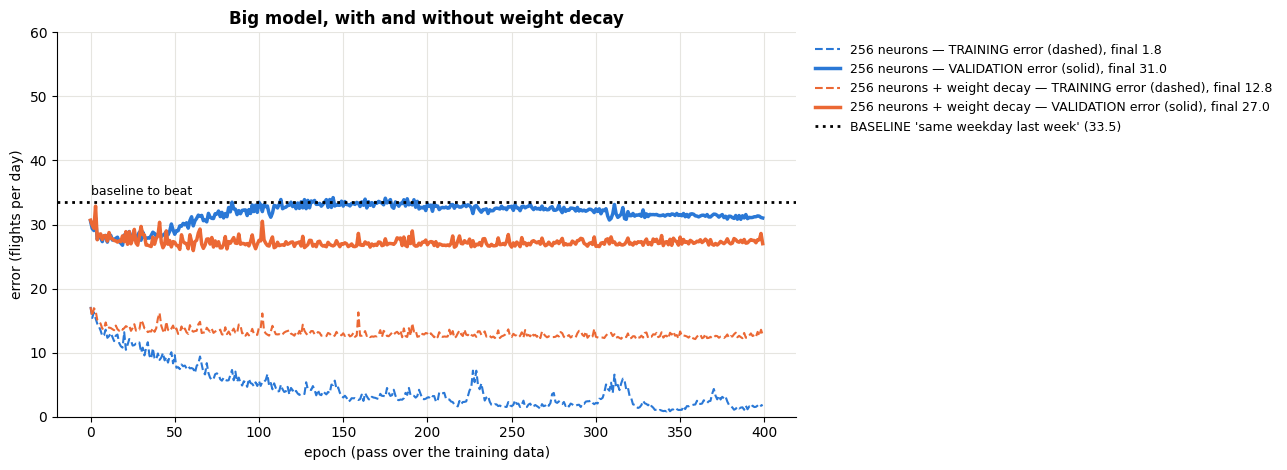

In [22]:
big_with_decay = train_model(hidden=256, epochs=400, weight_decay=0.01)   # the big model again, with weight decay
big_without_decay = size_results[2]                              # the big model without weight decay (3rd result above)

decay_runs = [big_without_decay, big_with_decay]                 # the two runs to compare
decay_labels = ["256 neurons", "256 neurons + weight decay"]     # names for the legend
plot_learning_curves(decay_runs, decay_labels, "Big model, with and without weight decay")  # draw them

📖 **Reading:** with weight decay the training error stays realistic (it cannot memorise) and the validation error stays low and flat. **Regularisation** like this is itself a hyperparameter.

### 7.3 Look-back — how many past days the model sees

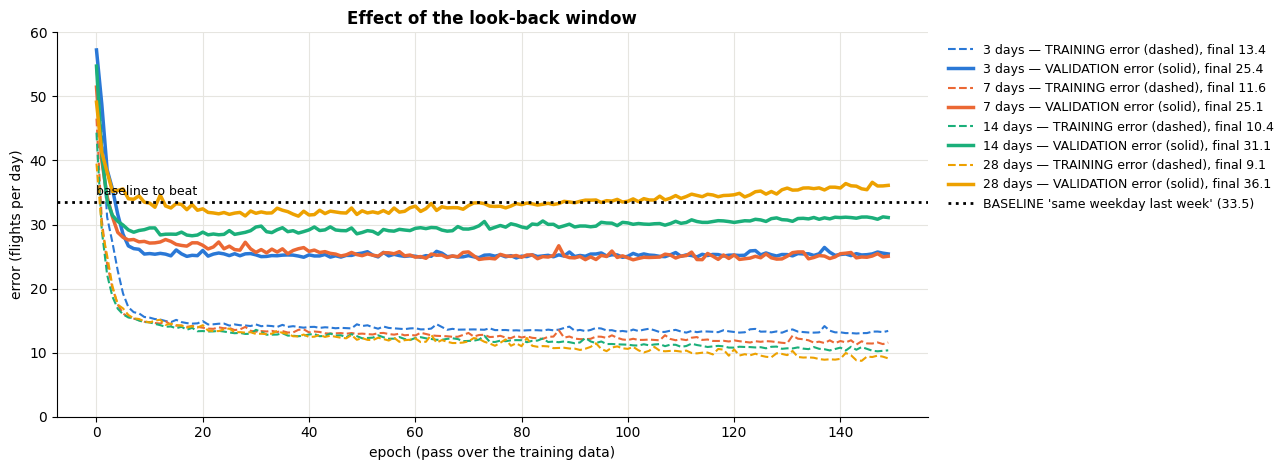

In [23]:
lookbacks = [3, 7, 14, 28]                                       # four look-back windows (in days)
lookback_results = []                                            # empty list for the results

for lookback in lookbacks:                                       # for each look-back...
    result = train_model(lookback=lookback)                      # ...train a model...
    lookback_results.append(result)                              # ...and keep its results

lookback_labels = ["3 days", "7 days", "14 days", "28 days"]     # names for the legend
plot_learning_curves(lookback_results, lookback_labels, "Effect of the look-back window")  # draw the four runs

📖 **Reading:** short windows (3 and 7 days) give the best validation error; **28 days is clearly worse** — even worse than the baseline.
More inputs mean more weights to learn from the same ~700 examples, so the model overfits. 7 days already contains *"the same weekday last week"*, the most useful information (§2.6).
**More input is not automatically better.**

### 🧑‍💻 Optional coding challenge B — the batch size
*Optional, for those who want to write code.*

**Task:** the batch size (how many examples the model sees before each correction) is another hyperparameter.
Train three models with `batch_size` = 8, 32 and 128 and draw their learning curves, following the pattern of §7.1.
**Variation:** also print the training time of each run (`result["seconds"]`). Which is fastest, and why?

Solution: `solutions/Lab1_airport_traffic_SOLUTIONS.ipynb`

batch 8 -> trained in 12.6 seconds


batch 32 -> trained in 3.7 seconds


batch 128 -> trained in 1.5 seconds


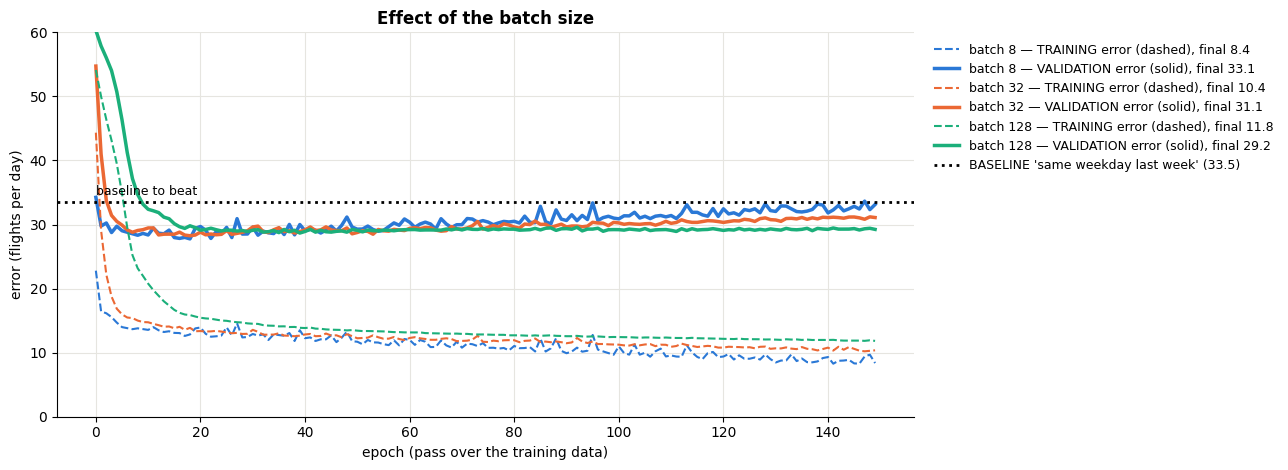

In [24]:
# 🧑‍💻 OPTIONAL CHALLENGE B — SOLUTION
batch_sizes = [8, 32, 128]                                   # three batch sizes to compare
batch_results = []                                           # empty list for the results

for batch_size in batch_sizes:                               # for each batch size...
    result = train_model(batch_size=batch_size)              # ...train a model...
    batch_results.append(result)                             # ...and keep its results
    print("batch", batch_size, "-> trained in", round(result["seconds"], 1), "seconds")   # variation: training time

batch_labels = ["batch 8", "batch 32", "batch 128"]          # names for the legend
plot_learning_curves(batch_results, batch_labels, "Effect of the batch size")   # draw the three runs
# Reading: small batches (8) make many small, noisy corrections: the curve is jumpy, training is slower to compute
# and the model overfits a little. Large batches (128) make few corrections per epoch: they start more slowly,
# but each epoch is much quicker and here they end with the best validation error.

### 7.4 All experiments in one table

In [25]:
all_results = []                                                 # one list with every run made so far
all_results.append(first_run)                                    # the first run
all_results.extend(lr_results)                                   # the learning-rate runs
all_results.extend(size_results)                                 # the model-size runs
all_results.append(big_with_decay)                               # the weight-decay run
all_results.extend(lookback_results)                             # the look-back runs

rows = []                                                        # one table row per run
for result in all_results:                                       # for each run...
    row = dict(result["settings"])                               # ...start the row with its settings...
    row["training error"] = round(result["final_train_mae"], 1)            # ...add its final training error...
    row["validation error"] = round(result["final_validation_mae"], 1)     # ...its final validation error...
    row["seconds"] = round(result["seconds"], 1)                 # ...and its training time
    rows.append(row)                                             # add the row to the list

summary = pd.DataFrame(rows)                                     # turn the rows into a table
summary = summary.sort_values("validation error")                # sort: best validation error first
summary                                                          # display the table

,lookback,hidden,learning_rate,epochs,batch_size,weight_decay,training error,validation error,seconds
9,7,32,0.00100,150,32,0.00,11.6,25.1,3.8
8,3,32,0.00100,150,32,0.00,13.4,25.4,3.9
7,14,256,0.00100,400,32,0.01,12.8,27.0,34.6
4,14,8,0.00100,400,32,0.00,12.8,27.6,9.3
3,14,32,0.10000,150,32,0.00,14.5,28.1,4.6
6,14,256,0.00100,400,32,0.00,1.8,31.0,27.3
0,14,32,0.00100,150,32,0.00,10.4,31.1,7.1
2,14,32,0.00100,150,32,0.00,10.4,31.1,4.1
10,14,32,0.00100,150,32,0.00,10.4,31.1,3.6
11,28,32,0.00100,150,32,0.00,9.1,36.1,3.8


**Try it yourself (optional):** change the numbers in the next cell and run it again. Can you find settings with a lower validation error?
Ideas: `batch_size=8` or `128`, `learning_rate=0.003`, `lookback=7` with `hidden=16`, fewer `epochs`…

In [26]:
my_run = train_model(lookback=7, hidden=32, learning_rate=0.001, epochs=150, batch_size=32, weight_decay=0.0)  # change me

print("My settings -> training error:", round(my_run["final_train_mae"], 1),
      "  validation error:", round(my_run["final_validation_mae"], 1))   # show the result
all_results.append(my_run)                                       # add it to the list, so it can win in the next section

My settings -> training error: 11.6   validation error: 25.1


---
## 8 · Final test (used only once)

We pick the run with the **lowest validation error** and check it, once, on the **test period** (July–December 2025) that no model has seen so far.

In [27]:
best = all_results[0]                                            # start by assuming the first run is the best
for result in all_results:                                       # look at every run...
    if result["final_validation_mae"] < best["final_validation_mae"]:  # ...if it has a lower validation error...
        best = result                                            # ...it becomes the new best
print("Best settings on validation:", best["settings"])          # show the winning settings

best_data = best["data"]                                         # the data of the best run
best_model = best["model"]                                       # the trained model of the best run

test_forecast = forecast_in_flights(best_model, best_data, best_data["test"])  # model forecasts on the test days
test_truth = best_data["y_flights"][best_data["test"]]           # true traffic on the test days
test_dates = best_data["dates"][best_data["test"]]               # the test dates
baseline_test = series.shift(7).loc[test_dates].values           # baseline forecast on the same days

model_error = mean_absolute_error(test_forecast, test_truth)     # test error of the model
baseline_error = mean_absolute_error(baseline_test, test_truth)  # test error of the baseline

print()                                                          # empty line
print("TEST error of the model   :", round(model_error, 1), "flights per day")      # show the model's error
print("TEST error of the baseline:", round(baseline_error, 1), "flights per day")   # show the baseline's error
print("Average traffic in the test period:", round(test_truth.mean()), "flights per day")  # for comparison

Best settings on validation: {'lookback': 7, 'hidden': 32, 'learning_rate': 0.001, 'epochs': 150, 'batch_size': 32, 'weight_decay': 0.0}

TEST error of the model   : 19.4 flights per day
TEST error of the baseline: 25.9 flights per day
Average traffic in the test period: 565 flights per day


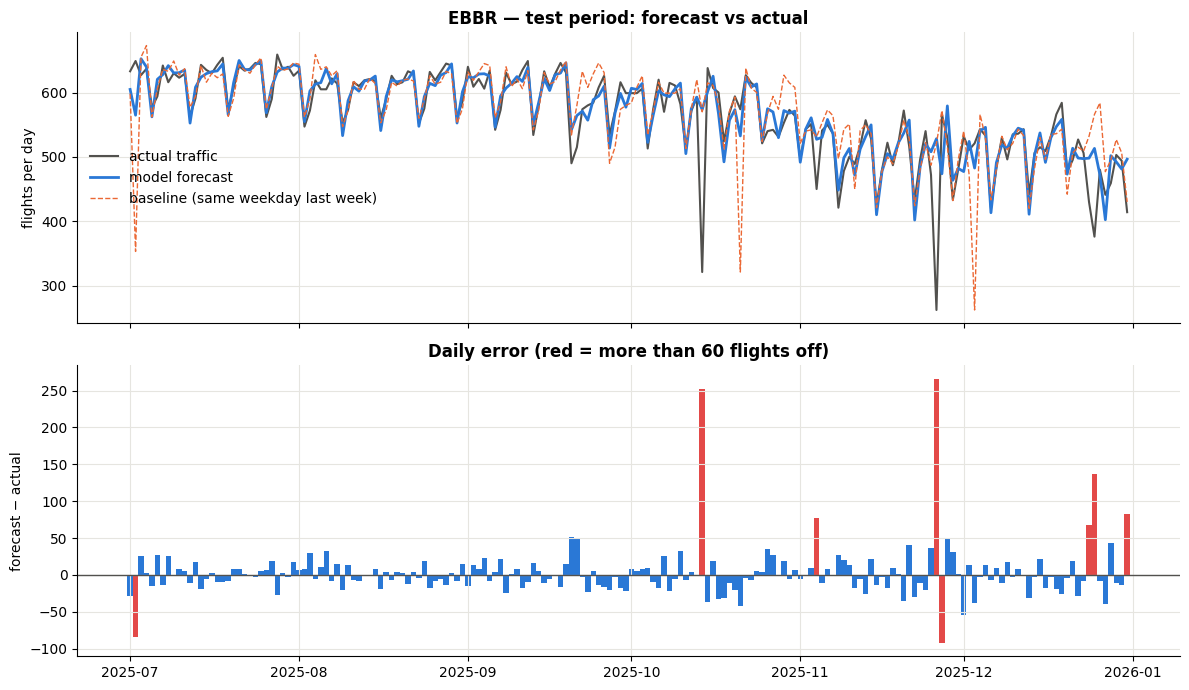

In [28]:
daily_error = test_forecast - test_truth                         # error on each test day (positive = too high)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)     # two plots, one above the other, same time axis

axes[0].plot(test_dates, test_truth, color="#52514e", linewidth=1.5, label="actual traffic")    # reality (grey)
axes[0].plot(test_dates, test_forecast, color=PALETTE[0], label="model forecast")               # model (blue)
axes[0].plot(test_dates, baseline_test, color=PALETTE[1], linewidth=1, linestyle="--",
             label="baseline (same weekday last week)")          # baseline (orange, dashed)
axes[0].set_ylabel("flights per day")                            # vertical axis label
axes[0].set_title(AIRPORT + " — test period: forecast vs actual")  # title
axes[0].legend()                                                 # legend

bar_colours = []                                                 # one colour per bar
for error in daily_error:                                        # for each daily error...
    if abs(error) > 60:                                          # ...if it is larger than 60 flights...
        bar_colours.append(PALETTE[7])                           # ...colour it red
    else:                                                        # otherwise...
        bar_colours.append(PALETTE[0])                           # ...colour it blue
axes[1].bar(test_dates, daily_error, color=bar_colours, width=1) # draw one bar per day
axes[1].axhline(0, color="#52514e", linewidth=1)                 # horizontal line at zero error
axes[1].set_ylabel("forecast − actual")                          # vertical axis label
axes[1].set_title("Daily error (red = more than 60 flights off)")  # title

plt.tight_layout()                                               # adjust spacing
plt.show()                                                       # display the figure

📖 **Reading:** the model follows the weekly rhythm closely and is usually better than the baseline. The large red bars are isolated disruption days and holidays — let's list them.

In [29]:
worst = pd.DataFrame()                                           # an empty table
worst["date"] = test_dates                                       # column: the test dates
worst["actual"] = test_truth                                     # column: true traffic
worst["forecast"] = np.round(test_forecast)                      # column: forecast, rounded
worst["error"] = np.round(daily_error)                           # column: error, rounded
worst["size of error"] = np.abs(worst["error"])                  # column: size of the error, without sign
worst["weekday"] = worst["date"].dt.day_name()                   # column: name of the weekday
worst = worst.sort_values("size of error", ascending=False)      # sort: largest errors first
worst.head(8)                                                    # display the 8 largest errors

,date,actual,forecast,error,size of error,weekday
148,2025-11-26,262.0,528.0,266.0,266.0,Wednesday
105,2025-10-14,321.0,574.0,253.0,253.0,Tuesday
177,2025-12-25,376.0,513.0,137.0,137.0,Thursday
149,2025-11-27,566.0,474.0,-92.0,92.0,Thursday
1,2025-07-02,649.0,565.0,-84.0,84.0,Wednesday
183,2025-12-31,414.0,496.0,82.0,82.0,Wednesday
126,2025-11-04,450.0,527.0,77.0,77.0,Tuesday
176,2025-12-24,430.0,498.0,68.0,68.0,Wednesday


### 🧑‍💻 Optional coding challenge C — early stopping
*Optional, for those who want to write code.*

The learning curves of the first run (§6.1) show that the validation error is lowest after a few dozen epochs and then slowly rises.
**Early stopping** means stopping the training at that point.

**Task:** find the epoch with the lowest validation error in `first_run`, train a new model for exactly that many epochs, and compare its test error with the model above.

Solution: `solutions/Lab1_airport_traffic_SOLUTIONS.ipynb`

In [30]:
# 🧑‍💻 OPTIONAL CHALLENGE C — SOLUTION
errors = first_run["validation_errors"]                      # validation error after each epoch of the first run
best_epoch = 0                                               # start by assuming epoch 0 is the best
for epoch in range(len(errors)):                             # look at every epoch...
    if errors[epoch] < errors[best_epoch]:                   # ...if its error is lower than the best so far...
        best_epoch = epoch                                   # ...remember this epoch
print("Lowest validation error at epoch", best_epoch, ":", round(errors[best_epoch], 1), "flights")   # show it

short_run = train_model(epochs=best_epoch + 1)               # train again, stopping right after the best epoch
short_forecast = forecast_in_flights(short_run["model"], short_run["data"], short_run["data"]["test"])   # test forecasts
print("Test error with early stopping:", round(mean_absolute_error(short_forecast, test_truth), 1), "flights")   # compare
print("Test error of the model chosen above:", round(model_error, 1), "flights")                                  # with this

Lowest validation error at epoch 18 : 28.2 flights


Test error with early stopping: 20.1 flights
Test error of the model chosen above: 19.4 flights


---
## 8.1 Save the model for Parts 2 and 3
We save the best model — its learned weights **and** everything needed to use it again: how many past days it needs, the scaling values, and its results.
Part 2 will open it and look inside; Part 3 will turn it into a small service.

In [31]:
import sys                                                       # sys: lets Python find our shared file
LAB_DIR = Path(".").resolve()                                    # this lab's folder...
if not (LAB_DIR / "traffic_core.py").exists():                   # ...or, from the solutions folder...
    LAB_DIR = LAB_DIR.parent                                     # ...the folder above
sys.path.insert(0, str(LAB_DIR))                                 # let Python find traffic_core.py
import traffic_core                                              # the shared code of Parts 2 and 3

card = {}                                                        # the "model card": a description of the model
card["name"] = "Next-day IFR traffic forecast " + AIRPORT        # name
card["version"] = "1.0.0"                                        # version
card["airport"] = AIRPORT                                        # airport
card["task"] = "Total IFR movements (FLT_TOT_1) of the next day"  # what it predicts
card["lookback"] = best["settings"]["lookback"]                  # how many past days it needs
card["hidden"] = best["settings"]["hidden"]                      # neurons per layer
card["mean"] = float(best_data["mean"])                          # scaling average (training period)
card["std"] = float(best_data["std"])                            # scaling spread (training period)
card["settings"] = best["settings"]                              # all training settings
card["validation_mae"] = round(best["final_validation_mae"], 1)  # error on Jan–Jun 2025
card["test_mae"] = round(model_error, 1)                         # error on Jul–Dec 2025
card["baseline_test_mae"] = round(baseline_error, 1)             # error of 'same weekday last week' on the test period
card["intended_use"] = "Training exercise only. Not for operational use."   # allowed use
traffic_core.save_model(best_model, card, LAB_DIR / "artifacts") # save weights + card in the artifacts folder

saved = traffic_core.SavedTrafficModel(LAB_DIR / "artifacts")    # load it back from disk, as Parts 2 and 3 will do
X_raw, y_raw, dates_raw = traffic_core.make_examples(series, saved.lookback)   # the examples, rebuilt by the shared code
check = saved.forecast_many(X_raw[dates_raw >= TEST_START])      # its forecasts on the test period
print("Saved model: look-back", saved.lookback, "days,", card["hidden"], "neurons per layer")   # what was saved
print("Largest difference with the model in memory:", float(np.abs(check - test_forecast).max()), "flights")   # ~0

Saved model: look-back 7 days, 32 neurons per layer
Largest difference with the model in memory: 0.0 flights


---
## 9 · Questions for discussion
1. In §7.2 the 256-neuron model had the **lowest training error**. Why would we *not* use it?
2. The worst test days are strikes, industrial action and holidays. What **extra information** could help — and would it be known the day before?
3. We chose the best settings using the validation period. Why would it be wrong to choose them using the test period?
4. Is an improvement of a few flights per day over the baseline **useful in operations**? Who would use this forecast, and for what?

➡️ **Next: Part 2 — Inside the model** (`Lab1_part2_inside_the_model.ipynb`), then **Part 3 — the model as a service** (`Lab1_part3_serve.ipynb`).

## 10 · Ideas to explore further (optional)
- Change `AIRPORT` in §2.2 (for example `"LIRF"`, `"LSZH"`, `"EGLL"`) and run the whole notebook again (*Run → Run All Cells*). Are the best settings the same?
- In §7.4, try different combinations of settings.
- In `train_model`, replace `nn.MSELoss()` with `nn.L1Loss()` (which penalises big errors less). Are strike days less harmful?

## ⚠️ Things that often go wrong in ML projects
> - **Data leakage:** letting the model see information from the future (random split, or scaling with statistics from the whole period). Always split by time and compute the scaling on the training data only.
> - **Judging a model on its training error:** a low training error says nothing about new data — always look at the validation curve.
> - **Using the test data more than once:** each extra look makes the final score less honest.